=== Verification N = 11 ===
Sequence: +++---+--+-
E = 5
F = 12.1

=== Benchmark ===
N = 20
Known optimum E* = 26
Known optimum F* = 7.6923076923076925

=== LABS N = 20 Results ===
Method                           E_best   F_best     r          N_eval     Time(s)   
-------------------------------------------------------------------------------------
Random Sampling                  42       4.7619     0.6190     10000      0.4559    
Best sequence: -++-++---+++-+-+----

Simulated Annealing              34       5.8824     0.7647     10000      0.3632    
Best sequence: +-++-+-+++-+++-----+

VQE-like Quantum Sampler         50       4.0000     0.5200     24000      11.0866   
Best sequence: -------+++--+--++-+-

Quantum-seeded Local Search      42       4.7619     0.6190     24000      11.1897   
Best sequence: +++++---++--+--+-+-+

Tabu Search                      26       7.6923     1.0000     3000000    0.0611    
Best sequence: +--+++--+-+++-+-----



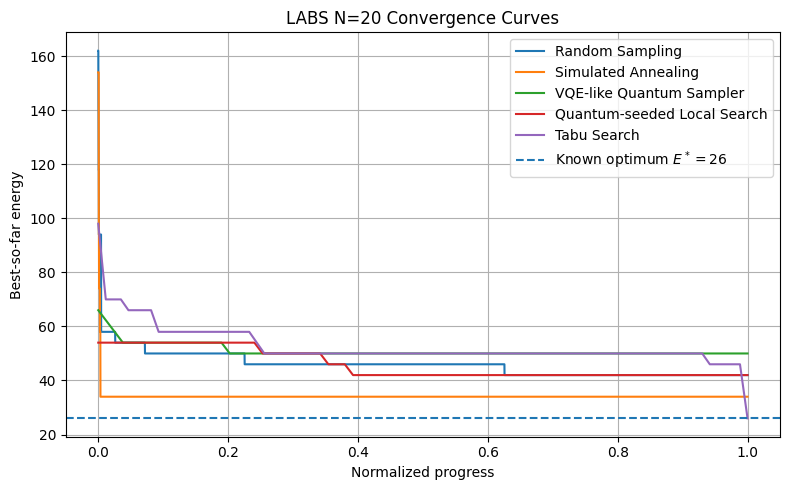

In [12]:
import numpy as np
import time
import matplotlib.pyplot as plt

import pennylane as qml
from scipy.optimize import minimize

SEED = 13202050

np.random.seed(SEED)
# =========================
# LABS cost functions
# =========================

def labs_energy(s):
    """
    Compute LABS energy:
    E(s) = sum_{k=1}^{N-1} C_k(s)^2
    where C_k(s) = sum_{i=1}^{N-k} s_i s_{i+k}.
    """
    N = len(s)
    E = 0

    for k in range(1, N):
        Ck = np.sum(s[:N-k] * s[k:])
        E += Ck**2

    return int(E)


def merit_factor(s):
    N = len(s)
    E = labs_energy(s)
    return N**2 / (2 * E)


def merit_ratio(s, F_star):
    return merit_factor(s) / F_star


def bits_to_spins(bits):
    """
    Convert 0/1 bits to -1/+1 spins.
    0 -> -1
    1 -> +1
    """
    return 2 * np.array(bits, dtype=int) - 1


def spins_to_string(s):
    return "".join("+" if x == 1 else "-" for x in s)


# =========================
# Verification for N = 11
# =========================

test_seq_str = "+++---+--+-"
test_seq = np.array([1 if c == "+" else -1 for c in test_seq_str])

print("=== Verification N = 11 ===")
print("Sequence:", test_seq_str)
print("E =", labs_energy(test_seq))
print("F =", merit_factor(test_seq))


# =========================
# Problem setting N = 20
# =========================

N = 20
E_star = 26
F_star = N**2 / (2 * E_star)

print("\n=== Benchmark ===")
print("N =", N)
print("Known optimum E* =", E_star)
print("Known optimum F* =", F_star)


# =========================
# Baseline 1: Random sampling
# =========================

def random_sampling(N, num_samples=10000):
    best_s = None
    best_E = float("inf")
    convergence = []

    start = time.time()

    for _ in range(num_samples):
        s = np.random.choice([-1, 1], size=N)
        E = labs_energy(s)

        if E < best_E:
            best_E = E
            best_s = s.copy()

        convergence.append(best_E)

    runtime = time.time() - start
    return best_s, best_E, convergence, runtime


# =========================
# Baseline 2: Classical simulated annealing
# =========================

def simulated_annealing(N, steps=10000, T0=10.0, Tend=0.001):
    s = np.random.choice([-1, 1], size=N)
    E = labs_energy(s)

    best_s = s.copy()
    best_E = E
    convergence = []

    start = time.time()

    for t in range(steps):
        T = T0 * (Tend / T0) ** (t / steps)

        i = np.random.randint(N)
        s_new = s.copy()
        s_new[i] *= -1

        E_new = labs_energy(s_new)
        dE = E_new - E

        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            s = s_new
            E = E_new

        if E < best_E:
            best_E = E
            best_s = s.copy()

        convergence.append(best_E)

    runtime = time.time() - start
    return best_s, best_E, convergence, runtime


# =========================
# Quantum Strategy 1: VQE-like quantum sampler
# =========================

shots = 300
dev = qml.device("default.qubit", wires=N, shots=shots)


def ansatz(params):
    """
    Hardware-efficient ansatz:
    Ry rotations + ring CNOT entanglers.
    """
    layers = params.shape[0]

    for layer in range(layers):
        for i in range(N):
            qml.RY(params[layer, i], wires=i)

        for i in range(N - 1):
            qml.CNOT(wires=[i, i + 1])

        qml.CNOT(wires=[N - 1, 0])


@qml.qnode(dev)
def sample_circuit(params):
    ansatz(params)
    return qml.sample(wires=range(N))


def vqe_quantum_sampler(N, layers=1, maxiter=80, shots_per_iter=300):
    global shots, dev, sample_circuit

    shots = shots_per_iter
    dev = qml.device("default.qubit", wires=N, shots=shots)

    @qml.qnode(dev)
    def sample_circuit_local(params):
        ansatz(params)
        return qml.sample(wires=range(N))

    sample_circuit = sample_circuit_local

    init_params = np.random.uniform(0, 2*np.pi, size=(layers, N))

    best_s = None
    best_E = float("inf")
    convergence = []

    start = time.time()

    def objective(x):
        nonlocal best_s, best_E

        params = x.reshape((layers, N))
        samples = sample_circuit(params)

        energies = []

        for bits in samples:
            s = bits_to_spins(bits)
            E = labs_energy(s)
            energies.append(E)

            if E < best_E:
                best_E = E
                best_s = s.copy()

        convergence.append(best_E)

        return np.mean(energies)

    result = minimize(
        objective,
        init_params.flatten(),
        method="COBYLA",
        options={"maxiter": maxiter}
    )

    opt_params = result.x.reshape((layers, N))
    runtime = time.time() - start
    N_eval = maxiter * shots_per_iter

    return best_s, best_E, convergence, runtime, N_eval, opt_params


# =========================
# Quantum Strategy 2: Quantum-seeded local search
# =========================

def local_search_from_seed_with_trace(seed_s, max_steps=200):
    s = seed_s.copy()
    E = labs_energy(s)

    best_s = s.copy()
    best_E = E
    trace = [best_E]

    for _ in range(max_steps):
        improved = False
        indices = np.random.permutation(len(s))

        for i in indices:
            s_new = s.copy()
            s_new[i] *= -1
            E_new = labs_energy(s_new)

            if E_new < E:
                s = s_new
                E = E_new
                improved = True

                if E < best_E:
                    best_E = E
                    best_s = s.copy()

                break

        trace.append(best_E)

        if not improved:
            break

    return best_s, best_E, trace


def quantum_seeded_local_search(opt_params, layers=1, num_seeds=80, max_steps=200):
    samples = sample_circuit(opt_params)

    candidates = []

    for bits in samples:
        s = bits_to_spins(bits)
        E = labs_energy(s)
        candidates.append((E, s))

    candidates.sort(key=lambda x: x[0])
    seeds = [s for E, s in candidates[:num_seeds]]

    best_s = None
    best_E = float("inf")
    convergence = []

    start = time.time()

    for seed_s in seeds:
        s_new, E_new, trace = local_search_from_seed_with_trace(
            seed_s,
            max_steps=max_steps
        )

        if E_new < best_E:
            best_E = E_new
            best_s = s_new.copy()

        convergence.append(best_E)

    runtime = time.time() - start

    return best_s, best_E, convergence, runtime

# =========================
# Strong classical / hybrid refinement: Tabu Search
# =========================

def tabu_search(N, max_iter=3000, tabu_tenure=7, num_restarts=50):
    global_best_s = None
    global_best_E = float("inf")
    convergence = []

    start = time.time()

    for restart in range(num_restarts):
        s = np.random.choice([-1, 1], size=N)
        E = labs_energy(s)

        best_s = s.copy()
        best_E = E

        tabu_until = np.zeros(N, dtype=int)

        for t in range(max_iter):
            best_move = None
            best_move_E = float("inf")
            best_candidate = None

            for i in range(N):
                s_new = s.copy()
                s_new[i] *= -1
                E_new = labs_energy(s_new)

                # Tabu rule with aspiration criterion
                if t < tabu_until[i] and E_new >= global_best_E:
                    continue

                if E_new < best_move_E:
                    best_move_E = E_new
                    best_move = i
                    best_candidate = s_new

            if best_candidate is None:
                continue

            s = best_candidate
            E = best_move_E
            tabu_until[best_move] = t + tabu_tenure

            if E < best_E:
                best_E = E
                best_s = s.copy()

            if E < global_best_E:
                global_best_E = E
                global_best_s = s.copy()

            convergence.append(global_best_E)

            if global_best_E == 26:
                runtime = time.time() - start
                return global_best_s, global_best_E, convergence, runtime

    runtime = time.time() - start
    return global_best_s, global_best_E, convergence, runtime
# =========================
# Run all methods
# =========================

results = []

# Random sampling
s_rand, E_rand, conv_rand, time_rand = random_sampling(
    N,
    num_samples=10000
)

results.append((
    "Random Sampling",
    s_rand,
    E_rand,
    merit_factor(s_rand),
    merit_ratio(s_rand, F_star),
    10000,
    time_rand
))

# Simulated annealing
s_sa, E_sa, conv_sa, time_sa = simulated_annealing(
    N,
    steps=10000,
    T0=10.0,
    Tend=0.001
)

results.append((
    "Simulated Annealing",
    s_sa,
    E_sa,
    merit_factor(s_sa),
    merit_ratio(s_sa, F_star),
    10000,
    time_sa
))

# VQE-like quantum sampler
s_vqe, E_vqe, conv_vqe, time_vqe, Neval_vqe, opt_params = vqe_quantum_sampler(
    N,
    layers=1,
    maxiter=80,
    shots_per_iter=300
)

results.append((
    "VQE-like Quantum Sampler",
    s_vqe,
    E_vqe,
    merit_factor(s_vqe),
    merit_ratio(s_vqe, F_star),
    Neval_vqe,
    time_vqe
))

# Quantum-seeded local search
s_hybrid, E_hybrid, conv_hybrid, time_hybrid = quantum_seeded_local_search(
    opt_params,
    layers=1,
    num_seeds=80,
    max_steps=200
)

results.append((
    "Quantum-seeded Local Search",
    s_hybrid,
    E_hybrid,
    merit_factor(s_hybrid),
    merit_ratio(s_hybrid, F_star),
    Neval_vqe,
    time_vqe + time_hybrid
))

# Tabu search
s_tabu, E_tabu, conv_tabu, time_tabu = tabu_search(
    N,
    max_iter=3000,
    tabu_tenure=7,
    num_restarts=50
)

tabu_evals = 3000 * 50 * N

results.append((
    "Tabu Search",
    s_tabu,
    E_tabu,
    merit_factor(s_tabu),
    merit_ratio(s_tabu, F_star),
    tabu_evals,
    time_tabu
))

# =========================
# Print comparison table
# =========================

print("\n=== LABS N = 20 Results ===")
print(f"{'Method':<32} {'E_best':<8} {'F_best':<10} {'r':<10} {'N_eval':<10} {'Time(s)':<10}")
print("-" * 85)

for method, s, E, F, r, Neval, runtime in results:
    print(f"{method:<32} {E:<8} {F:<10.4f} {r:<10.4f} {Neval:<10} {runtime:<10.4f}")
    print("Best sequence:", spins_to_string(s))
    print()


# =========================
# Improved convergence plot
# =========================

def normalized_x(conv):
    return np.linspace(0, 1, len(conv))


plt.figure(figsize=(8, 5))

plt.plot(normalized_x(conv_rand), conv_rand, label="Random Sampling")
plt.plot(normalized_x(conv_sa), conv_sa, label="Simulated Annealing")
plt.plot(normalized_x(conv_vqe), conv_vqe, label="VQE-like Quantum Sampler")
plt.plot(normalized_x(conv_hybrid), conv_hybrid, label="Quantum-seeded Local Search")
plt.plot(normalized_x(conv_tabu), conv_tabu, label="Tabu Search")
plt.axhline(E_star, linestyle="--", label=r"Known optimum $E^*=26$")

plt.xlabel("Normalized progress")
plt.ylabel("Best-so-far energy")
plt.title("LABS N=20 Convergence Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("labs_convergence_improved.png", dpi=300)
plt.show()